# Native UpSet plots

Composable set intersections for differential-expression results

`ggnomics.upset` is a native [plotnine](https://plotnine.org)
implementation of set-intersection (“UpSet”) plots, in the style of
[ComplexUpset](https://github.com/krassowski/complex-upset). It has no
runtime dependency on the Matplotlib-based `upsetplot` package — every
plot it returns is an ordinary `plotnine.composition.Compose` object,
buildable from panels you can inspect, theme, and recompose like any
other plotnine figure.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path("_includes").resolve()))
from setup import configure_warnings, ensure_matplotlib_initialized
ensure_matplotlib_initialized()  # see the import-order note in _includes/setup.py
configure_warnings()

import numpy as np
import pandas as pd
import ggnomics as gg
import ggnomics.upset as upset
from plotnine import (
    aes, geom_bar, geom_boxplot, geom_col, geom_point, geom_segment, ggplot,
    labs, theme, theme_bw,
)
from plotnine.composition import plot_annotation

## 1. Why use an UpSet plot?

A Venn diagram is unreadable past three or four sets: circle overlaps
stop being legible, and areas cannot be made exactly proportional in
general. UpSet plots trade the geometric layout for a matrix — one row
per set, one column per *intersection* — annotated with bar charts of
intersection size. This scales cleanly to many sets and makes exact set
membership legible at a glance, at the cost of not being a familiar
circle diagram.

Here, we compare which genes are called differentially expressed (DE) at
each of the three E-MTAB-1625 salt-stress timepoints — a natural
three-to-many-set overlap question that a Venn diagram handles poorly
once more timepoints or contrasts are added.

## 2. Data source and selection rule

We reuse the three matched salt-vs-control PyDESeq2 fits already
computed for [Bulk RNA-seq](bulk-rnaseq.ipynb) and [Specialized
plots](specialized-plots.ipynb), from the same E-MTAB-1625 rice
salt-stress experiment (see [datasets.yml](https://github.com/MaximilianNuber/ggnomics/blob/main/vignettes/datasets.yml)):

In [2]:
from data import run_deseq2_on_emtab1625

timepoints = ["1 hour", "5 hour", "24 hour"]
fits = {timepoint: run_deseq2_on_emtab1625(timepoint) for timepoint in timepoints}

The package’s documented significance rule for `mode="upset"` (see
[Section 13](#13.-Native-plot_pseudobulk_de(mode="upset"))) is `padj < 0.05` and
`abs(log2FoldChange) >= 1`. Applying it here, before assuming any
overlap is interesting:

In [3]:
strict_sig = {}
for timepoint, fit in fits.items():
    res = fit["results"].dropna(subset=["log2FoldChange", "padj"])
    sig = res.loc[(res["padj"] < 0.05) & (res["log2FoldChange"].abs() >= 1)]
    strict_sig[timepoint] = set(sig.index)

{timepoint: len(genes) for timepoint, genes in strict_sig.items()}

{'1 hour': 10, '5 hour': 4, '24 hour': 487}

In [4]:
print("1h & 24h:", len(strict_sig["1 hour"] & strict_sig["24 hour"]))
print("5h & 24h:", len(strict_sig["5 hour"] & strict_sig["24 hour"]))
print("1h & 5h:", len(strict_sig["1 hour"] & strict_sig["5 hour"]))
print("all three:", len(strict_sig["1 hour"] & strict_sig["5 hour"] & strict_sig["24 hour"]))

1h & 24h: 2
5h & 24h: 1
1h & 5h: 0
all three: 0

This is a real and biologically sensible result, not an artifact: the
salt response strengthens substantially between 1 hour and 24 hours, so
1-hour (10 genes) and 5-hour (4 genes) contribute too few significant
genes at this threshold to show an informative *intersection* structure
— the overlaps above are 0-2 genes. [Section
13](#13.-Native-plot_pseudobulk_de(mode="upset")) shows this exact, honest result
via `plot_pseudobulk_de`.

To demonstrate the rest of the API’s features on a richer, still-real
overlap, Sections 4-12 and 14 instead use a clearly labeled
**descriptive, top-ranked** rule: the 300 genes with the largest
`abs(log2FoldChange)` at each timepoint, regardless of `padj`. This is
descriptive (a ranking), not a significance claim — it deliberately is
not read as “these genes are DE”; see the callout in [Section
15](#15.-Statistical-helper-caution).

In [5]:
TOP_N = 300
top_ranked = {}
for timepoint, fit in fits.items():
    res = fit["results"].dropna(subset=["log2FoldChange"])
    ranked = res.reindex(res["log2FoldChange"].abs().sort_values(ascending=False).index)
    top_ranked[timepoint] = set(ranked.head(TOP_N).index)

{timepoint: len(genes) for timepoint, genes in top_ranked.items()}

{'1 hour': 300, '5 hour': 300, '24 hour': 300}

In [6]:
print("1h & 24h:", len(top_ranked["1 hour"] & top_ranked["24 hour"]))
print("5h & 24h:", len(top_ranked["5 hour"] & top_ranked["24 hour"]))
print("1h & 5h:", len(top_ranked["1 hour"] & top_ranked["5 hour"]))
print("all three:", len(top_ranked["1 hour"] & top_ranked["5 hour"] & top_ranked["24 hour"]))

1h & 24h: 14
5h & 24h: 34
1h & 5h: 24
all three: 2

## 3. Constructing the Boolean membership table

`ggnomics.upset` takes one row per element (here, gene) and one Boolean
column per set (here, timepoint) — plus any extra columns you want
available to custom annotations.

In [7]:
timepoint_columns = [tp.replace(" ", "_") for tp in timepoints]
all_genes = sorted(set.union(*top_ranked.values()))

membership = pd.DataFrame({"gene_id": all_genes})
for timepoint, column in zip(timepoints, timepoint_columns):
    membership[column] = membership["gene_id"].isin(top_ranked[timepoint])

logfc_by_timepoint = pd.DataFrame(
    {column: fits[tp]["results"]["log2FoldChange"] for tp, column in zip(timepoints, timepoint_columns)}
).reindex(all_genes)
# .to_numpy(): logfc_by_timepoint is indexed by gene ID (from reindex(all_genes)),
# while `membership` has a plain positional index built in the same gene order —
# a plain Series assignment here would align on (mismatched) index and produce NaN.
membership["max_abs_log2fc"] = logfc_by_timepoint.abs().max(axis=1).to_numpy()
membership["timepoint_of_max_effect"] = logfc_by_timepoint.abs().idxmax(axis=1).to_numpy()

membership.head()

In [8]:
membership.shape

(830, 6)

## 4. Basic native UpSet plot

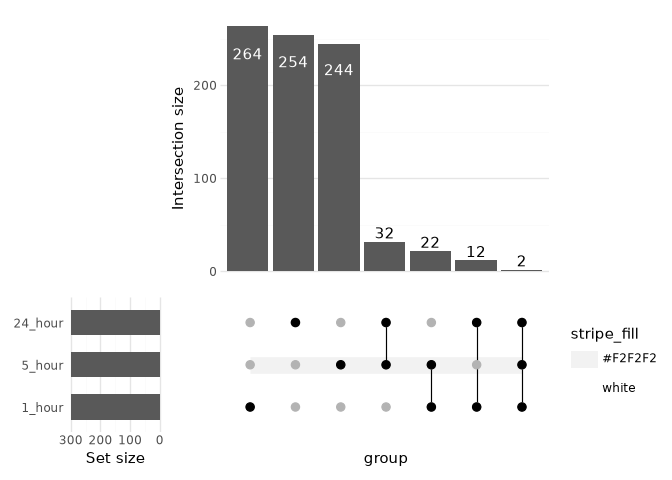

In [9]:
upset.upset(membership, timepoint_columns)

## 5. Inspecting the computation

`upset()` and `upset_data()` are convenience wrappers around three
independently usable, independently testable steps:
`compute_intersections` -\> `select_intersections` -\>
`apply_intersection_selection`.

In [10]:
statistics = upset.compute_intersections(membership, intersect=timepoint_columns)
statistics.sizes

In [11]:
selection = upset.select_intersections(statistics, min_size=5, sort_intersections="descending")
selection.intersections

('I1', 'I2', 'I0', 'I4', 'I5', 'I6')

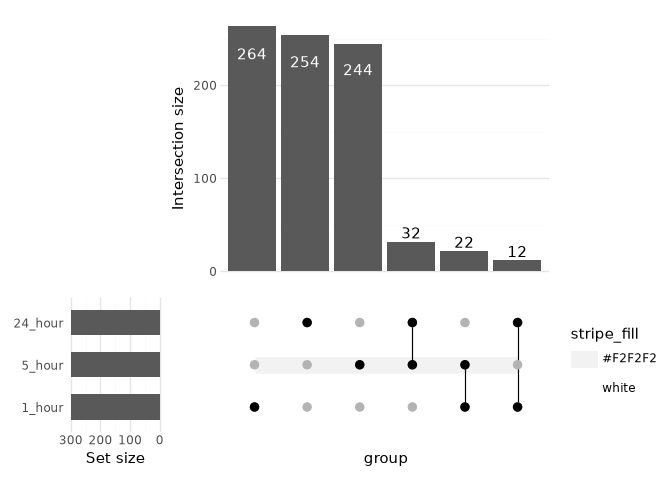

In [12]:
prepared = upset.apply_intersection_selection(statistics, selection=selection)
upset.upset(prepared)

## 6. Four region-selection modes

ComplexUpset (and `ggnomics.upset`) define four ways to count how an
element relates to a target combination of sets, controlled by `mode=`.
The exact semantics are easiest to see on `create_upset_abc_example()`,
a fixed 325-row example with three sets A/B/C and known counts:

In [13]:
abc_example = upset.create_upset_abc_example()
abc_statistics = upset.compute_intersections(abc_example, intersect=["A", "B", "C"], intersections="all")
target = next(
    identifier for identifier, members in abc_statistics.intersection_members.items()
    if members == ("A", "B")
)
abc_statistics.sizes.loc[[target]]

For the target combination `("A", "B")`:

| Mode | Meaning | Value |
|------------------------|------------------------|------------------------|
| `exclusive_intersection` (“distinct”) | elements in A and B, and nothing else | 10 |
| `inclusive_intersection` (“intersect”) | elements in at least A and B (may also be in C) | 11 |
| `exclusive_union` | elements in at least one of A, B, and nothing outside {A, B} | 110 |
| `inclusive_union` (“union”) | elements in at least one of A or B | 123 |

`exclusive_intersection` (“distinct”) is what the intersection-size bars
show by default — it is what a reader expects an UpSet bar to mean; the
other three answer related but different questions and are mainly used
by the ratio annotation and the statistical helpers.

## 7. Filtering and sorting intersections

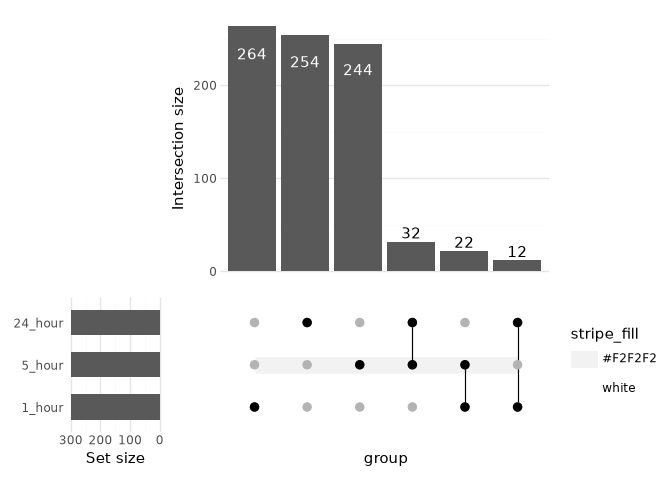

In [14]:
upset.upset(
    membership,
    timepoint_columns,
    min_size=10,
    sort_intersections_by=["cardinality"],
    sort_intersections="descending",
)

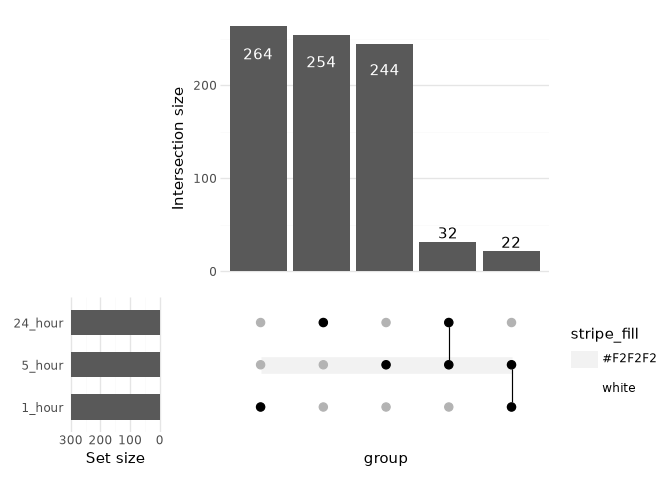

In [15]:
upset.upset(membership, timepoint_columns, n_intersections=5)

## 8. Set and intersection highlighting

`upset_query()` highlights a specific set (`set=`) or intersection
(`intersect=`) with extra plotting aesthetics, applied everywhere it is
relevant (or restricted with `only_components=`).

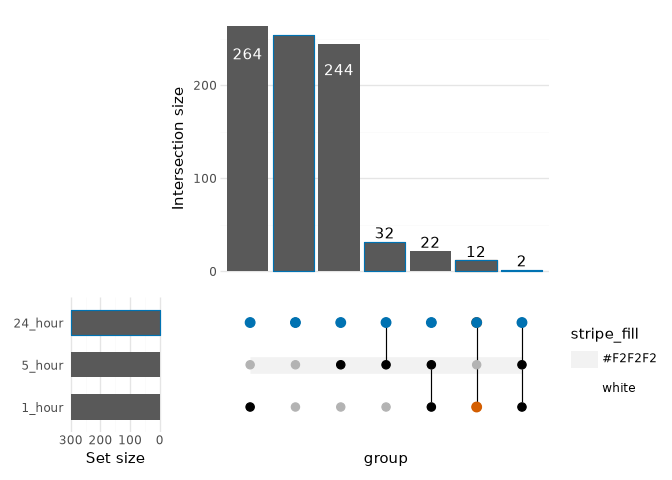

In [16]:
upset.upset(
    membership,
    timepoint_columns,
    queries=[
        upset.upset_query(intersect=["1_hour", "24_hour"], color="#D55E00"),
        upset.upset_query(set="24_hour", color="#0072B2"),
    ],
)

## 9. Intersection-size and ratio annotations

`intersection_ratio()` adds a second panel showing each intersection’s
size relative to `inclusive_union` by default — how much of the total
involved elements a given combination accounts for.

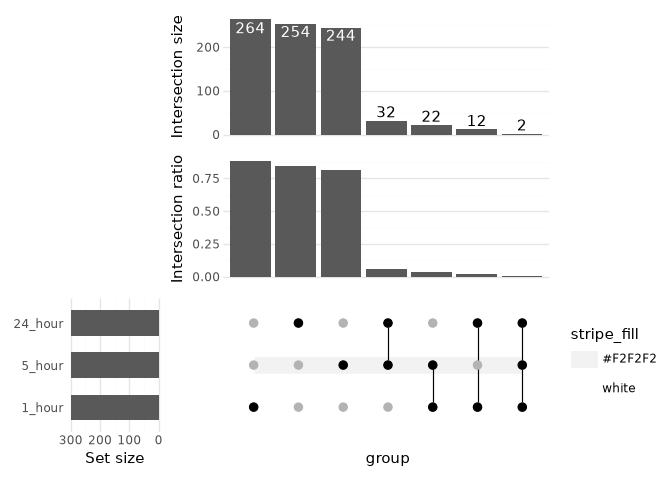

In [17]:
upset.upset(
    membership,
    timepoint_columns,
    base_annotations={
        "Intersection size": upset.intersection_size(),
        # counts=False: the default "numerator/denominator" labels overlap on
        # the narrow low-ratio bars here; the bar heights already show the
        # ratio clearly at this width.
        "Intersection ratio": upset.intersection_ratio(counts=False),
    },
)

## 10. A custom annotation based on log2 fold change

`upset_annotate()` builds an annotation panel from any numeric column
already present in the membership table plus any Plotnine geom(s) —
here, a boxplot of `max_abs_log2fc` per intersection.

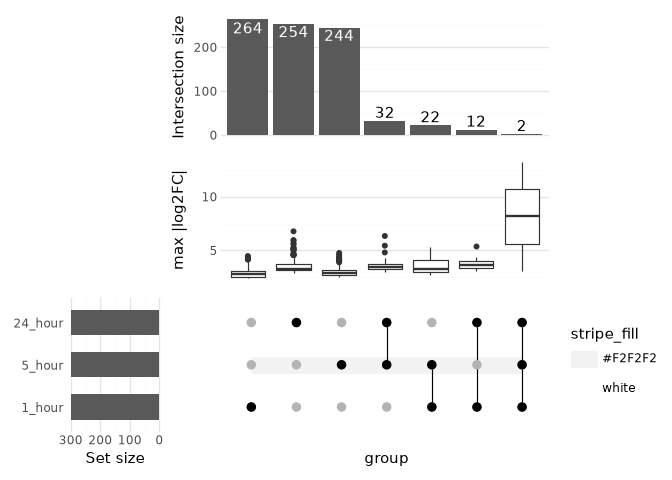

In [18]:
upset.upset(
    membership,
    timepoint_columns,
    annotations={
        "max |log2FC|": upset.upset_annotate("max_abs_log2fc", geom_boxplot()),
    },
)

## 11. Matrix, stripes, and set-size customization

The membership matrix, its background stripes, and the marginal set-size
panel are each independently swappable specifications.

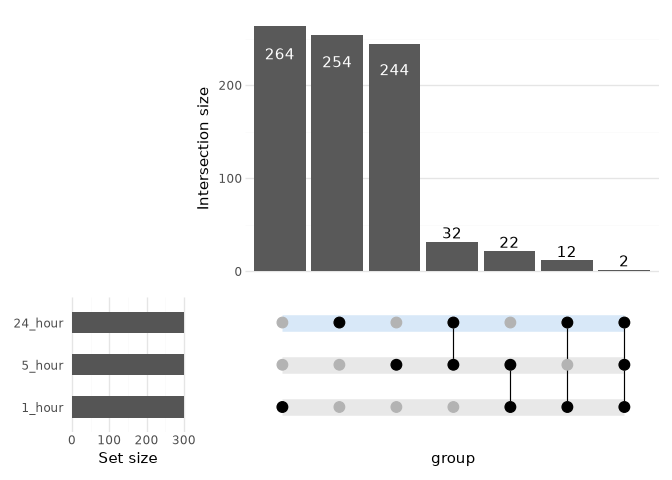

In [19]:
stripe_metadata = pd.DataFrame({
    "set": timepoint_columns,
    "phase": ["early", "early", "late"],
})
upset.upset(
    membership,
    timepoint_columns,
    matrix=upset.intersection_matrix(geom=geom_point(size=4)),
    stripes=upset.upset_stripes(
        mapping={"color": "phase"},
        colors={"early": "#E8E8E8", "late": "#D8E8F8"},
        data=stripe_metadata,
    ),
    set_sizes=upset.upset_set_size(position="right", geom=geom_col(width=0.5, fill="#555555")),
)

## 12. Composition with another Plotnine plot

Because `upset()` returns a `plotnine.composition.Compose`, it composes
with ordinary plotnine plots using the same `|` and `/` operators as any
other ggnomics composition:

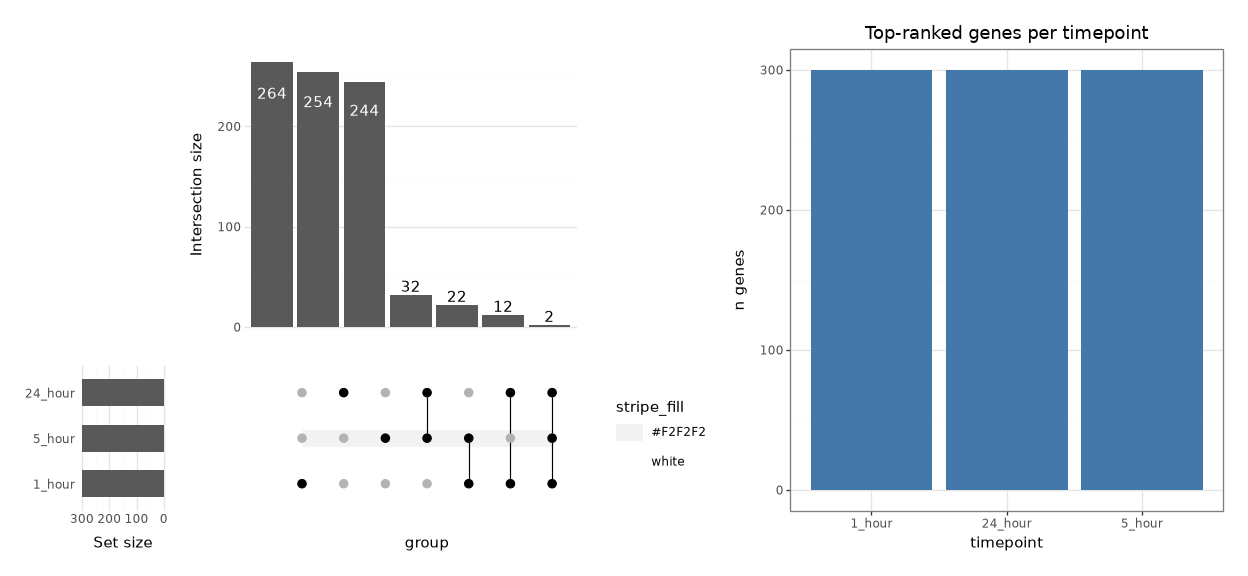

In [20]:
overlap_summary = pd.DataFrame({
    "timepoint": timepoint_columns,
    "n_top_ranked": [len(top_ranked[tp]) for tp in timepoints],
})
bar = (
    ggplot(overlap_summary, aes(x="timepoint", y="n_top_ranked"))
    + geom_bar(stat="identity", fill="#4477AA")
    + theme_bw()
    + labs(title="Top-ranked genes per timepoint", y="n genes")
)
combined = (upset.upset(membership, timepoint_columns) | bar) + plot_annotation(
    theme=theme(figure_size=(13, 6))
)
combined

## 13. Native `plot_pseudobulk_de(mode="upset")`

`plot_pseudobulk_de` accepts a `dict[str, DataFrame]` of DE result
tables directly (no pre-built membership table needed) and returns a
native `Compose` object — the same underlying `ggnomics.upset.upset()`
backend used throughout this vignette, with the default `padj < 0.05` /
`abs(log2FoldChange) >= 1` significance rule from [Section
2](#2.-Data-source-and-selection-rule):

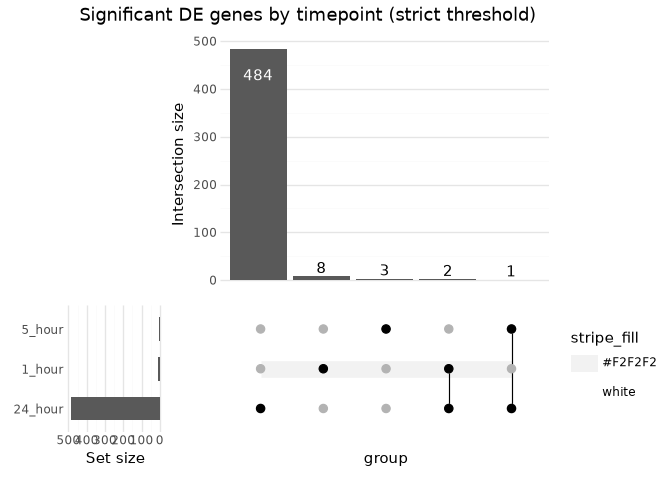

In [21]:
per_timepoint_results = {
    tp.replace(" ", "_"): fit["results"] for tp, fit in fits.items()
}
gg.plot_pseudobulk_de(
    per_timepoint_results, mode="upset", title="Significant DE genes by timepoint (strict threshold)"
)

This is the honest result at the package’s default significance
threshold: almost no genes are called significant at 1 or 5 hours, so
almost no cross-timepoint bars appear — a real finding about this
dataset (the salt response has barely started at 1-5 hours), not a
plotting limitation.

## 14. Venn representation for a small two-/three-set comparison

For two or three sets, `ggnomics.upset` also provides an approximate
geometric/raster Venn representation — useful as a familiar shape for
small comparisons; region areas are visually indicative, not exactly
proportional.

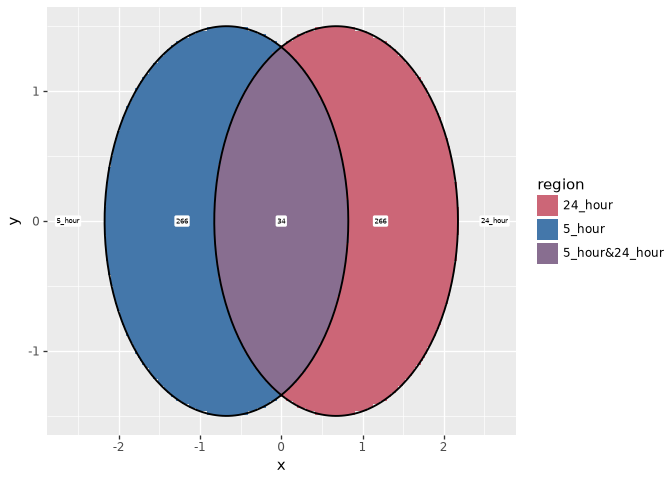

In [22]:
venn_membership = membership[["5_hour", "24_hour"]].copy()
venn_layout = upset.arrange_venn(venn_membership, sets=["5_hour", "24_hour"])
(
    ggplot()
    + upset.geom_venn_region(venn_layout)
    + upset.geom_venn_circle(venn_layout)
    + upset.geom_venn_label_region(venn_layout)
    + upset.geom_venn_label_set(venn_layout)
    + upset.scale_fill_venn_mix(venn_layout, colors=["#4477AA", "#CC6677"])
)

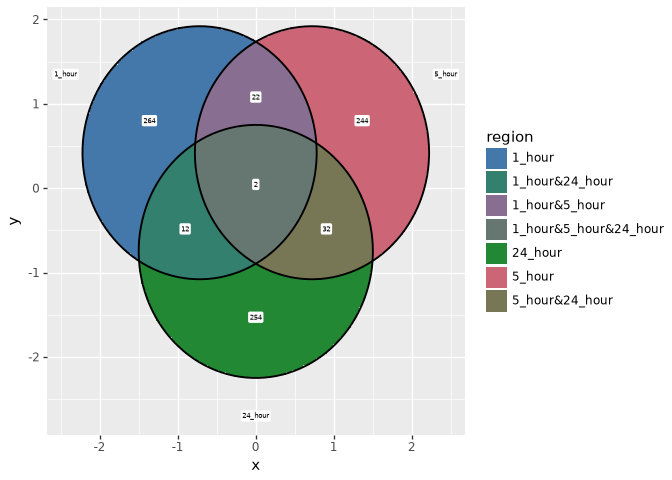

In [23]:
venn_layout_3 = upset.arrange_venn(membership, sets=timepoint_columns)
(
    ggplot()
    + upset.geom_venn_region(venn_layout_3)
    + upset.geom_venn_circle(venn_layout_3)
    + upset.geom_venn_label_region(venn_layout_3)
    + upset.geom_venn_label_set(venn_layout_3)
    + upset.scale_fill_venn_mix(venn_layout_3, colors=["#4477AA", "#CC6677", "#228833"])
)

## 15. Statistical-helper caution

`compare_between_intersections()` / `upset_test()` compare a covariate
across intersections (Kruskal-Wallis for numeric, chi-square for
categorical, by default). They are only inferentially valid when the
*rows* supplied represent appropriate independent statistical units.
Here, the rows are genes: this comparison is **descriptive of the
top-ranked gene table constructed above**, not an inference about
biological replicates — a per-gene p-value from this table must not be
read as “timepoints differ” in the way a per-sample/per-patient p-value
would be.

In [24]:
upset.upset_test(membership, timepoint_columns, ignore_mode_columns=True, ignore=["gene_id"])

## 16. Performance and combinatorial growth

`intersections="all"` materializes every one of the `2^n` possible
combinations of `n` sets — fine for the 8 combinations of 3 sets used
here, but it grows explosively (`2^10 = 1024`, `2^20 > 10^6`, …). For
more than a handful of sets, prefer the default
`intersections="observed"` (only combinations that actually occur) or an
explicit list of the combinations you care about; `upset_data()` also
raises before materializing an `intersections="all"` result that would
exceed `max_combinations_datapoints_n`.

## 17. See also

- [API reference](../api/modules.rst) — full signatures for every
  function used above.
- [Bulk RNA-seq](bulk-rnaseq.ipynb) — the PyDESeq2 fits reused here.
- [Plot gallery](plot-gallery.ipynb#Native-UpSet-plots) — a compact
  function table for `ggnomics.upset`.